In [96]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import f1_score,classification_report,confusion_matrix,accuracy_score

import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv('dataset.csv')
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [4]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [6]:
corr = df.corr()['target'].drop('target')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'age'),
  Text(1, 0, 'sex'),
  Text(2, 0, 'chest pain type'),
  Text(3, 0, 'resting bp s'),
  Text(4, 0, 'cholesterol'),
  Text(5, 0, 'fasting blood sugar'),
  Text(6, 0, 'resting ecg'),
  Text(7, 0, 'max heart rate'),
  Text(8, 0, 'exercise angina'),
  Text(9, 0, 'oldpeak'),
  Text(10, 0, 'ST slope')])

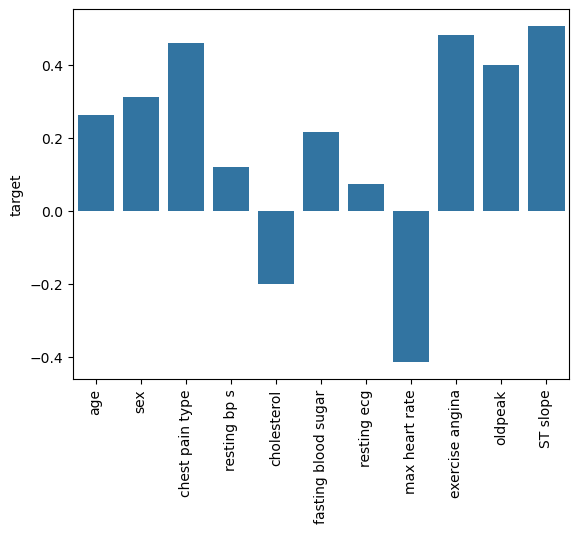

In [7]:
sns.barplot(corr)
plt.xticks(rotation = 90)

In [ ]:
X = df.drop('target',axis=1)
y = df['target']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [10]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

# Logistic Regression 

In [62]:
from sklearn.feature_selection import RFE

model = LogisticRegressionCV()
rfecv = RFE(estimator=model,n_features_to_select=5)
rfecv.fit(X_train,y_train)

,estimator,LogisticRegressionCV()
,n_features_to_select,5
,step,1
,verbose,0
,importance_getter,'auto'
,Cs,10
,fit_intercept,True
,cv,None
,dual,False
,penalty,'l2'
,scoring,None


In [63]:
CV_X_train = X_train[:,rfecv.support_]
CV_X_test = X_test[:,rfecv.support_]

In [64]:

parms = {'Cs':[5,10,15,20,50],
         'fit_intercept':[True,False],
         'cv':[5,10,15],
         'dual':[True,False],
         'penalty':['l1', 'l2', 'elasticnet']}

gcv  = GridSearchCV(estimator= model,param_grid= parms,cv=5)
gcv.fit(CV_X_train,y_train)
best_cv_model = gcv.best_estimator_


In [65]:
gcv.best_score_

np.float64(0.8385098236143369)

In [67]:
lr_best_model = gcv.best_estimator_
lr_best_model.fit(CV_X_train,y_train)


,Cs,10
,fit_intercept,True
,cv,5
,dual,False
,penalty,'l2'
,scoring,None
,solver,'lbfgs'
,tol,0.0001
,max_iter,100
,class_weight,None
,n_jobs,None


In [70]:
lr_predict = lr_best_model.predict(CV_X_test)

In [90]:
# accuracy_score = f1_score(lr_predict,y_test)
class_report = classification_report(lr_predict,y_test)
conf_matrix = confusion_matrix(lr_predict,y_test)

In [91]:
print(class_report)

              precision    recall  f1-score   support

           0       0.83      0.84      0.83       128
           1       0.88      0.87      0.87       170

    accuracy                           0.86       298
   macro avg       0.85      0.85      0.85       298
weighted avg       0.86      0.86      0.86       298



<Axes: >

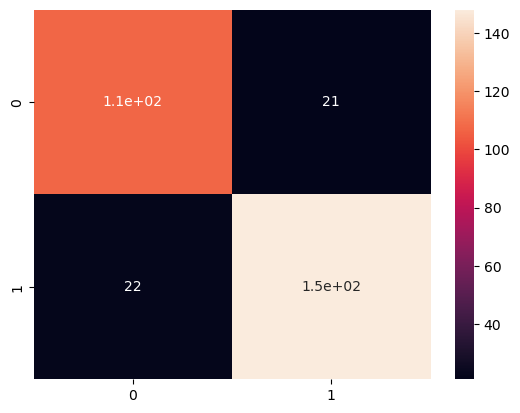

In [92]:
sns.heatmap(conf_matrix,annot=True)

# Decision Tree

In [80]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
rfeDT = RFE(estimator=model,n_features_to_select=5)
rfeDT.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,n_features_to_select,5
,step,1
,verbose,0
,importance_getter,'auto'
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [82]:
X_train_DT =X_train[:,rfeDT.support_]
X_test_DT =X_test[:,rfeDT.support_]


In [83]:
parms = {'criterion':['gini', 'entropy', 'log_loss'],
         'splitter':['best', 'random'],
         'max_depth':[1,5,10,15,50,100],
         'min_samples_split' :[1,3,5,15,50,100],
         'min_samples_leaf':[1,2,5,15,50,100],
         'max_features':['auto','sqrt','log2'],
         'random_state':[0,1,41,42]}
gcv_dt  = GridSearchCV(estimator = model,param_grid = parms,cv = 5)

gcv_dt.fit(X_train_DT,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 5, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [84]:
gcv_dt.best_estimator_

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,41
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [85]:
gcv_dt.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'random_state': 41,
 'splitter': 'best'}

In [86]:
gcv_dt.best_score_

np.float64(0.8318372983491307)

In [93]:
DT_best_model = gcv_dt.best_estimator_
DT_best_model.fit(X_train_DT,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,41
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [95]:
dt_train_predict = DT_best_model.predict(X_train_DT)
dt_test_predict = DT_best_model.predict(X_test_DT)

In [100]:
print('Training accuracy',f1_score(dt_train_predict,y_train))

Training accuracy 0.954248366013072


In [101]:
print('Testing accuracy',f1_score(dt_test_predict,y_test))

Testing accuracy 0.8459214501510574


<Axes: >

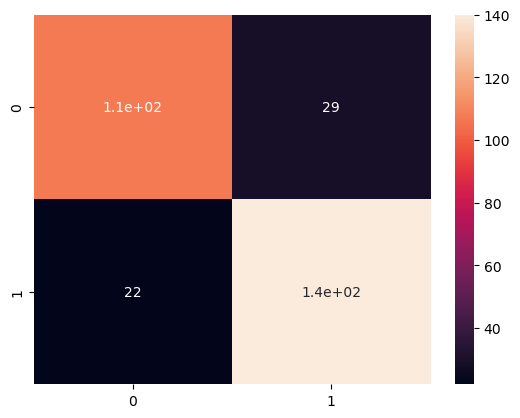

In [102]:
DT_conf_matrix = confusion_matrix(dt_test_predict,y_test)
sns.heatmap(DT_conf_matrix,annot= True)
    

In [104]:
print(classification_report(dt_test_predict,y_test))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81       136
           1       0.83      0.86      0.85       162

    accuracy                           0.83       298
   macro avg       0.83      0.83      0.83       298
weighted avg       0.83      0.83      0.83       298



# Random Forest 

In [105]:
from sklearn.ensemble import RandomForestClassifier

model_Rf = RandomForestClassifier()
rfe_rf = RFE(estimator=model,n_features_to_select=5)
rfe_rf.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,n_features_to_select,5
,step,1
,verbose,0
,importance_getter,'auto'
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [109]:
X_Rf_train = X_train[:,rfe_rf.support_]
X_Rf_test = X_test[:,rfe_rf.support_]

In [168]:
parms = {'n_estimators':[10,15,20],
         'criterion':['gini', 'entropy', 'log_loss'],
         'max_depth':[1,5,10,15],
         'min_samples_split' :[3,5,15],
         'min_samples_leaf':[2,5,15],
         'max_features':['auto','sqrt','log2']
         }

RF_CV = GridSearchCV(estimator=model_Rf,param_grid=parms,cv =9)
RF_CV.fit(X_Rf_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 5, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': [2, 5, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,9
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,10


In [170]:
RF_CV.best_estimator_

,n_estimators,10
,criterion,'log_loss'
,max_depth,15
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [171]:
best_mode_rf = RF_CV.best_estimator_
best_mode_rf.fit(X_Rf_train,y_train)
pred_train = best_mode_rf.predict(X_Rf_train)
pred_test = best_mode_rf.predict(X_Rf_test)
f1_train = f1_score(pred_train,y_train)
f1_test = f1_score(pred_test,y_test)


In [172]:
print('Trian Accuracy',f1_train)
print('Test Accuracy',f1_test)

Trian Accuracy 0.9512459371614301
Test Accuracy 0.8734939759036144


In [173]:
RF_CV.best_params_

{'criterion': 'log_loss',
 'max_depth': 15,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 3,
 'n_estimators': 10}

In [174]:
new_rf = RandomForestClassifier(criterion='log_loss',
                                max_depth=17,
                                max_features='sqrt',
                                min_samples_leaf=2,
                                min_samples_split=3,
                                n_estimators=17,
                                random_state=1)

In [175]:
new_rf.fit(X_train,y_train)
pred_train = new_rf.predict(X_train)
pred_test = new_rf.predict(X_test)
f1_train = f1_score(pred_train,y_train)
f1_test = f1_score(pred_test,y_test)

In [176]:
print('Trian Accuracy',f1_train)
print('Test Accuracy',f1_test)

Trian Accuracy 0.978401727861771
Test Accuracy 0.9470588235294117


# XG Boost Classifier 

In [178]:
from xgboost import XGBClassifier

model_xg = XGBClassifier()
rfe_XG = RFE(estimator=model_xg,n_features_to_select=9)
rfe_XG.fit(X_train,y_train)


,estimator,"XGBClassifier...ree=None, ...)"
,n_features_to_select,9
,step,1
,verbose,0
,importance_getter,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [181]:
X_train_XG = X_train[:,rfe_XG.support_]
X_test_XG = X_test[:,rfe_XG.support_]

In [182]:
parms = {
    'n_estimators' : [10,20,30],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth':[10,20,30],
    'gamma':[1,2]
}

gcv_XG = GridSearchCV(estimator=model_xg,param_grid=parms,cv = 5)
gcv_XG.fit(X_train_XG,y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'gamma': [1, 2], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [10, 20, ...], 'n_estimators': [10, 20, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [183]:
gcv_XG.best_estimator_

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [184]:
gcv_XG.best_params_

{'gamma': 1, 'learning_rate': 0.2, 'max_depth': 20, 'n_estimators': 20}

In [185]:
gcv_XG.best_score_

np.float64(0.8631724311091583)

In [186]:
XG_best = gcv_XG.best_estimator_